# COSC2671 — Assignment 2: NLP Analysis
## What Makes a YouTube Gaming Video Go Viral?

This notebook performs three layers of NLP analysis:

1. **VADER Sentiment Analysis** — classify comments as positive, negative, or neutral per video and virality tier
2. **LDA Topic Modelling** — identify dominant discussion themes per niche and virality tier
3. **TF-IDF Analysis** — extract keywords from video titles that distinguish viral from non-viral videos

**Inputs:** `data/videos.csv`, `data/comments.csv`  
**Outputs:** `data/comments_sentiment.csv`, `data/video_nlp_features.csv`, `data/lda_topics.csv`, figures

## Cell 1 — Install Dependencies

In [ ]:
# Run once
#!pip install nltk gensim scikit-learn pandas matplotlib seaborn wordcloud pyLDAvis

## Cell 2 — Imports & NLTK Downloads

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Gensim for LDA
import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

# Scikit-learn for TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

# WordCloud
from wordcloud import WordCloud

# Statistical tests
from scipy import stats

# NLTK downloads
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

# ── Load data ─────────────────────────────────────────────────────────────────
videos_df  = pd.read_csv('data/videos.csv')
comments_df = pd.read_csv('data/comments.csv')

# Drop rows missing text or author
comments_df = comments_df[comments_df['text'].notna()]
comments_df = comments_df[comments_df['text'].str.strip() != '']

# Map video tier and niche to comments
video_tier  = dict(zip(videos_df['video_id'], videos_df['virality_tier']))
video_niche = dict(zip(videos_df['video_id'], videos_df['niche']))
comments_df['virality_tier'] = comments_df['video_id'].map(video_tier)
comments_df['niche']         = comments_df['video_id'].map(video_niche)

NICHES      = videos_df['niche'].unique().tolist()
TIER_ORDER  = ['viral', 'mid', 'non_viral']
TIER_COLORS = {'viral': '#2ecc71', 'mid': '#f39c12', 'non_viral': '#e74c3c'}

print(f"Videos:   {len(videos_df):,}")
print(f"Comments: {len(comments_df):,}")
print(f"Niches:   {NICHES}")

Videos:   558
Comments: 46,259
Niches:   ['minecraft', 'valorant', 'gta6']


## Cell 3 — Text Preprocessing

In [3]:
lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))

# Add gaming-specific stop words that carry no analytical value
GAMING_STOPWORDS = {
    'like', 'video', 'game', 'gaming', 'play', 'played', 'playing',
    'youtube', 'channel', 'subscribe', 'comment', 'watch', 'watching',
    'lol', 'lmao', 'omg', 'yeah', 'oh', 'ok', 'okay', 'hey', 'hi',
    'minecraft', 'valorant', 'gta', 'gta6', 'really', 'actually',
    'know', 'think', 'want', 'make', 'go', 'get', 'got', 'good', 'great'
}
STOP_WORDS.update(GAMING_STOPWORDS)


def clean_text(text):
    """
    Clean raw comment text:
    - Lowercase
    - Remove URLs, mentions, hashtags, emojis, punctuation
    - Collapse whitespace
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # Remove URLs
    text = re.sub(r'@\w+', '', text)                     # Remove @mentions
    text = re.sub(r'#\w+', '', text)                     # Remove hashtags
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)           # Remove non-ASCII (emojis)
    text = re.sub(r'[^a-z\s]', ' ', text)                # Remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()             # Collapse whitespace
    return text


def tokenize_and_lemmatize(text):
    """
    Tokenize, remove stopwords, lemmatize.
    Returns list of clean tokens (min length 3).
    """
    tokens = word_tokenize(text)
    tokens = [
        lemmatizer.lemmatize(t, pos='v')
        for t in tokens
        if t not in STOP_WORDS and len(t) >= 3
    ]
    return tokens


print("Cleaning comment text...")
comments_df['clean_text'] = comments_df['text'].apply(clean_text)
comments_df['tokens']     = comments_df['clean_text'].apply(tokenize_and_lemmatize)
comments_df['token_count'] = comments_df['tokens'].apply(len)

# Filter out very short comments (< 3 tokens) — not useful for LDA
comments_df = comments_df[comments_df['token_count'] >= 3]

print(f"Comments after cleaning: {len(comments_df):,}")
print(f"Avg tokens per comment:  {comments_df['token_count'].mean():.1f}")

Cleaning comment text...
Comments after cleaning: 29,193
Avg tokens per comment:  8.3


## Cell 4 — VADER Sentiment Analysis

In [4]:
print("Running VADER sentiment analysis...")

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    """
    Use VADER on the ORIGINAL (uncleaned) text to preserve
    capitalisation, punctuation, and emojis that VADER uses.
    Returns compound score and sentiment label.
    """
    scores = sia.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        label = 'positive'
    elif compound <= -0.05:
        label = 'negative'
    else:
        label = 'neutral'
    return pd.Series({
        'vader_compound': compound,
        'vader_pos': scores['pos'],
        'vader_neg': scores['neg'],
        'vader_neu': scores['neu'],
        'sentiment_label': label
    })

# Apply VADER to original text (not cleaned)
sentiment_scores = comments_df['text'].apply(get_sentiment)
comments_df = pd.concat([comments_df, sentiment_scores], axis=1)

# Save sentiment-enriched comments
comments_df.to_csv('data/comments_sentiment.csv', index=False)

print(f"Sentiment distribution:")
print(comments_df['sentiment_label'].value_counts())
print(f"\nAvg compound score: {comments_df['vader_compound'].mean():.4f}")

Running VADER sentiment analysis...
Sentiment distribution:
sentiment_label
positive    12886
neutral     11168
negative     5139
Name: count, dtype: int64

Avg compound score: 0.1545


## Cell 5 — Aggregate Sentiment per Video

In [5]:
# ── Aggregate sentiment metrics per video ─────────────────────────────────────
video_sentiment = (
    comments_df
    .groupby('video_id')
    .agg(
        avg_compound=('vader_compound', 'mean'),
        std_compound=('vader_compound', 'std'),
        pct_positive=('sentiment_label', lambda x: (x == 'positive').mean()),
        pct_negative=('sentiment_label', lambda x: (x == 'negative').mean()),
        pct_neutral=('sentiment_label', lambda x: (x == 'neutral').mean()),
        comment_count=('vader_compound', 'count')
    )
    .reset_index()
)

# Merge with video metadata
video_nlp = videos_df.merge(video_sentiment, on='video_id', how='left')

print("Sentiment by virality tier:")
print(video_nlp.groupby('virality_tier')[['avg_compound', 'pct_positive', 'pct_negative']]
      .mean().round(4))

print("\nSentiment by niche:")
print(video_nlp.groupby('niche')[['avg_compound', 'pct_positive', 'pct_negative']]
      .mean().round(4))

Sentiment by virality tier:
               avg_compound  pct_positive  pct_negative
virality_tier                                          
mid                  0.1499        0.4331        0.1668
non_viral            0.1152        0.4072        0.1996
viral                0.1776        0.4603        0.1653

Sentiment by niche:
           avg_compound  pct_positive  pct_negative
niche                                              
gta6             0.1331        0.4222        0.2109
minecraft        0.1533        0.4081        0.1145
valorant         0.1570        0.4715        0.2037


## Cell 6 — Statistical Test: Sentiment vs Virality

In [6]:
print("Statistical comparison of sentiment across virality tiers...\n")

# Mann-Whitney U test (non-parametric, doesn't assume normality)
# Compares viral vs non-viral sentiment distributions
viral_scores     = video_nlp[video_nlp['virality_tier'] == 'viral']['avg_compound'].dropna()
non_viral_scores = video_nlp[video_nlp['virality_tier'] == 'non_viral']['avg_compound'].dropna()
mid_scores       = video_nlp[video_nlp['virality_tier'] == 'mid']['avg_compound'].dropna()

u_stat, p_value = stats.mannwhitneyu(viral_scores, non_viral_scores, alternative='two-sided')
print(f"Mann-Whitney U Test: Viral vs Non-Viral sentiment")
print(f"  U statistic: {u_stat:.2f}")
print(f"  p-value:     {p_value:.6f}")
print(f"  Significant: {'YES' if p_value < 0.05 else 'NO'} (alpha=0.05)")

# Kruskal-Wallis across all three tiers
kw_stat, kw_p = stats.kruskal(viral_scores, mid_scores, non_viral_scores)
print(f"\nKruskal-Wallis Test: All three tiers")
print(f"  H statistic: {kw_stat:.2f}")
print(f"  p-value:     {kw_p:.6f}")
print(f"  Significant: {'YES' if kw_p < 0.05 else 'NO'} (alpha=0.05)")

# Effect size: rank-biserial correlation
n1, n2 = len(viral_scores), len(non_viral_scores)
r_effect = 1 - (2 * u_stat) / (n1 * n2)
print(f"\nEffect size (rank-biserial r): {r_effect:.4f}")
print(f"  Interpretation: {'Large' if abs(r_effect) > 0.5 else 'Medium' if abs(r_effect) > 0.3 else 'Small'} effect")

Statistical comparison of sentiment across virality tiers...

Mann-Whitney U Test: Viral vs Non-Viral sentiment
  U statistic: 12064.50
  p-value:     0.000043
  Significant: YES (alpha=0.05)

Kruskal-Wallis Test: All three tiers
  H statistic: 19.67
  p-value:     0.000054
  Significant: YES (alpha=0.05)

Effect size (rank-biserial r): -0.2859
  Interpretation: Small effect


## Cell 7 — Visualisation 1: Sentiment by Virality Tier

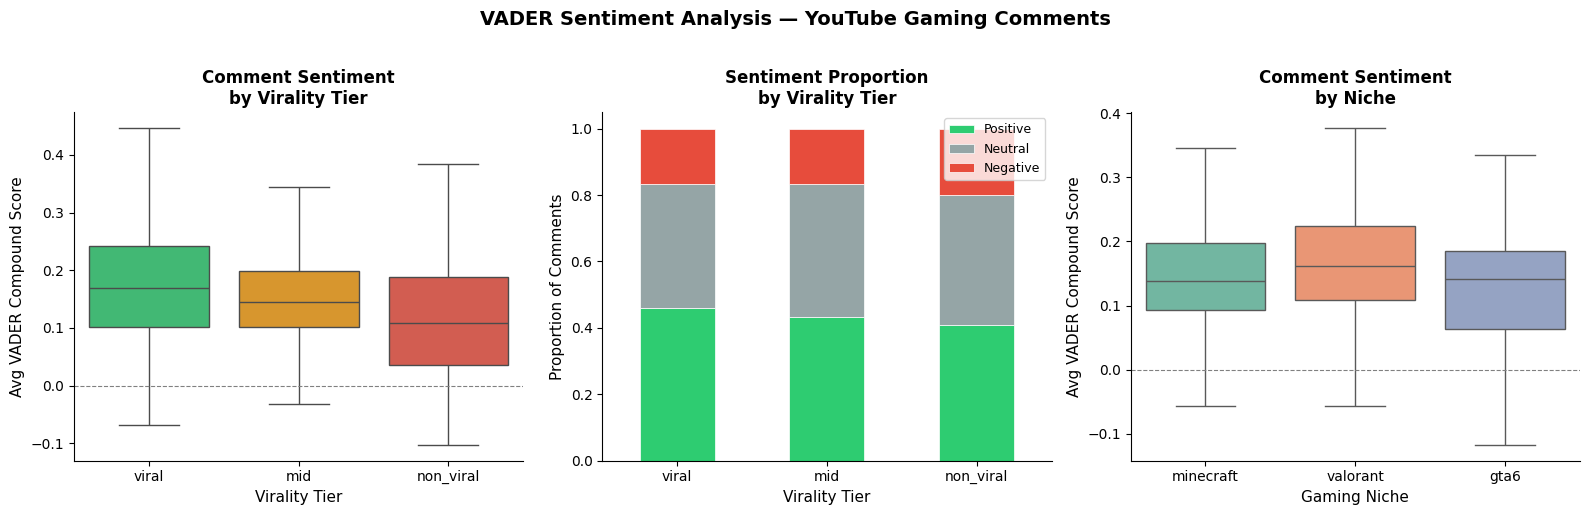

Saved: data/fig_sentiment_by_tier.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Boxplot: avg compound score by tier ───────────────────────────────────────
ax = axes[0]
plot_data = video_nlp[video_nlp['virality_tier'].isin(TIER_ORDER)]
sns.boxplot(data=plot_data, x='virality_tier', y='avg_compound',
            order=TIER_ORDER, palette=TIER_COLORS, ax=ax, showfliers=False)
ax.set_xlabel('Virality Tier', fontsize=11)
ax.set_ylabel('Avg VADER Compound Score', fontsize=11)
ax.set_title('Comment Sentiment\nby Virality Tier', fontsize=12, fontweight='bold')
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)

# ── Stacked bar: sentiment proportion by tier ─────────────────────────────────
ax2 = axes[1]
tier_sentiment = (
    plot_data.groupby('virality_tier')[['pct_positive', 'pct_neutral', 'pct_negative']]
    .mean()
    .reindex(TIER_ORDER)
)
tier_sentiment.plot(
    kind='bar', stacked=True, ax=ax2,
    color=['#2ecc71', '#95a5a6', '#e74c3c'],
    edgecolor='white', linewidth=0.5
)
ax2.set_xlabel('Virality Tier', fontsize=11)
ax2.set_ylabel('Proportion of Comments', fontsize=11)
ax2.set_title('Sentiment Proportion\nby Virality Tier', fontsize=12, fontweight='bold')
ax2.set_xticklabels(TIER_ORDER, rotation=0)
ax2.legend(['Positive', 'Neutral', 'Negative'], loc='upper right', fontsize=9)

# ── Boxplot by niche ──────────────────────────────────────────────────────────
ax3 = axes[2]
sns.boxplot(data=plot_data, x='niche', y='avg_compound',
            palette='Set2', ax=ax3, showfliers=False)
ax3.set_xlabel('Gaming Niche', fontsize=11)
ax3.set_ylabel('Avg VADER Compound Score', fontsize=11)
ax3.set_title('Comment Sentiment\nby Niche', fontsize=12, fontweight='bold')
ax3.axhline(0, color='grey', linestyle='--', linewidth=0.8)

plt.suptitle('VADER Sentiment Analysis — YouTube Gaming Comments', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/fig_sentiment_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/fig_sentiment_by_tier.png")

## Cell 8 — Visualisation 2: Sentiment Over Comment Engagement

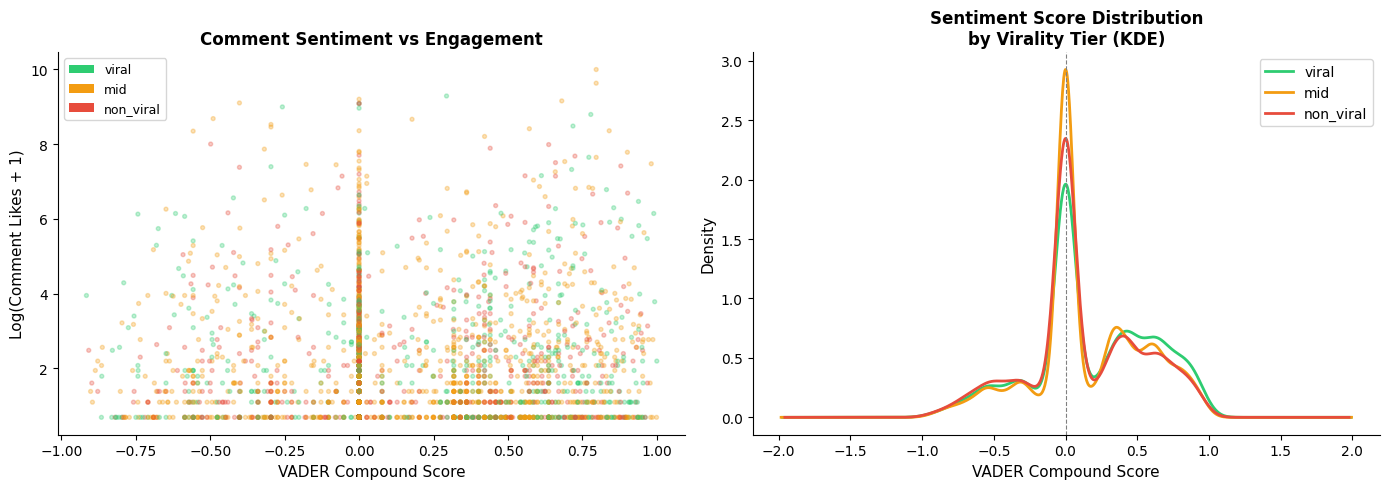

Saved: data/fig_sentiment_kde.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Scatter: comment like count vs sentiment ──────────────────────────────────
ax = axes[0]
sample = comments_df[comments_df['like_count'] > 0].sample(min(3000, len(comments_df)), random_state=42)
scatter_colors = [TIER_COLORS.get(t, 'grey') for t in sample['virality_tier']]
ax.scatter(sample['vader_compound'], np.log1p(sample['like_count']),
           c=scatter_colors, alpha=0.3, s=8)
ax.set_xlabel('VADER Compound Score', fontsize=11)
ax.set_ylabel('Log(Comment Likes + 1)', fontsize=11)
ax.set_title('Comment Sentiment vs Engagement', fontsize=12, fontweight='bold')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t) for t, c in TIER_COLORS.items()]
ax.legend(handles=legend_elements, fontsize=9)

# ── KDE plot: sentiment distribution by tier ──────────────────────────────────
ax2 = axes[1]
for tier in TIER_ORDER:
    tier_data = comments_df[comments_df['virality_tier'] == tier]['vader_compound']
    if len(tier_data) > 0:
        tier_data.plot.kde(ax=ax2, label=tier, color=TIER_COLORS[tier], linewidth=2)
ax2.set_xlabel('VADER Compound Score', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('Sentiment Score Distribution\nby Virality Tier (KDE)', fontsize=12, fontweight='bold')
ax2.axvline(0, color='grey', linestyle='--', linewidth=0.8)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('data/fig_sentiment_kde.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/fig_sentiment_kde.png")

## Cell 9 — LDA Topic Modelling

In [9]:
print("Building LDA topic models per niche...")

NUM_TOPICS = 5      # Topics per niche — adjust based on coherence scores
LDA_PASSES = 15     # Training passes — more = better but slower
RANDOM_STATE = 42

lda_results = {}    # Store model results per niche

for niche in NICHES:
    print(f"\n{'─'*50}")
    print(f"Niche: {niche.upper()}")

    niche_tokens = comments_df[comments_df['niche'] == niche]['tokens'].tolist()
    # Filter out empty token lists
    niche_tokens = [t for t in niche_tokens if len(t) >= 3]

    if len(niche_tokens) < 50:
        print(f"  Not enough data for LDA in niche '{niche}'. Skipping.")
        continue

    print(f"  Documents for LDA: {len(niche_tokens):,}")

    # ── Build dictionary and corpus ───────────────────────────────────────────
    # Filter extremes: ignore terms in <5 docs or >50% of docs
    dictionary = corpora.Dictionary(niche_tokens)
    dictionary.filter_extremes(no_below=5, no_above=0.5)
    corpus = [dictionary.doc2bow(tokens) for tokens in niche_tokens]

    print(f"  Vocabulary size: {len(dictionary):,} terms")

    # ── Train LDA model ───────────────────────────────────────────────────────
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=NUM_TOPICS,
        random_state=RANDOM_STATE,
        passes=LDA_PASSES,
        alpha='auto',           # Learn asymmetric priors from data
        eta='auto',
        per_word_topics=True
    )

    # ── Coherence score ───────────────────────────────────────────────────────
    coherence_model = CoherenceModel(
        model=lda_model, texts=niche_tokens,
        dictionary=dictionary, coherence='c_v'
    )
    coherence = coherence_model.get_coherence()
    print(f"  Coherence score (c_v): {coherence:.4f}")

    # ── Print topics ──────────────────────────────────────────────────────────
    print(f"  Topics:")
    topics = lda_model.print_topics(num_words=8)
    for tid, topic in topics:
        print(f"    Topic {tid}: {topic}")

    # ── Assign dominant topic per comment ─────────────────────────────────────
    niche_mask = comments_df['niche'] == niche
    niche_corpus = [dictionary.doc2bow(t) for t in comments_df.loc[niche_mask, 'tokens']]
    dominant_topics = []
    topic_probs = []
    for bow in niche_corpus:
        topic_dist = lda_model.get_document_topics(bow)
        if topic_dist:
            dominant = max(topic_dist, key=lambda x: x[1])
            dominant_topics.append(dominant[0])
            topic_probs.append(dominant[1])
        else:
            dominant_topics.append(-1)
            topic_probs.append(0.0)

    comments_df.loc[niche_mask, 'dominant_topic'] = dominant_topics
    comments_df.loc[niche_mask, 'topic_prob'] = topic_probs

    lda_results[niche] = {
        'model': lda_model,
        'dictionary': dictionary,
        'corpus': corpus,
        'coherence': coherence,
        'topics': topics
    }

print("\nLDA modelling complete.")

Building LDA topic models per niche...

──────────────────────────────────────────────────
Niche: MINECRAFT
  Documents for LDA: 9,972
  Vocabulary size: 2,079 terms
  Coherence score (c_v): 0.4920
  Topics:
    Topic 0: 0.011*"first" + 0.011*"one" + 0.011*"years" + 0.011*"name" + 0.010*"kon" + 0.010*"old" + 0.010*"man" + 0.010*"jai"
    Topic 1: 0.095*"love" + 0.083*"bro" + 0.028*"pls" + 0.025*"videos" + 0.022*"yes" + 0.021*"thank" + 0.013*"guy" + 0.009*"much"
    Topic 2: 0.059*"hai" + 0.055*"bhai" + 0.048*"carry" + 0.023*"durbin" + 0.021*"mein" + 0.021*"bhi" + 0.020*"aap" + 0.019*"aur"
    Topic 3: 0.019*"new" + 0.017*"happy" + 0.014*"would" + 0.013*"depie" + 0.011*"block" + 0.011*"add" + 0.011*"make" + 0.010*"day"
    Topic 4: 0.098*"please" + 0.058*"fan" + 0.052*"bhai" + 0.051*"carry" + 0.050*"big" + 0.048*"face" + 0.038*"reveal" + 0.021*"bhaiya"

──────────────────────────────────────────────────
Niche: VALORANT
  Documents for LDA: 8,563
  Vocabulary size: 1,777 terms
  Coherenc

## Cell 10 — LDA Topic Labels & Topic-Virality Mapping

In [10]:
# ── Manually label topics after inspecting Cell 9 output ─────────────────────
# Replace these placeholder labels with your own interpretations
# based on the top words printed in Cell 9
TOPIC_LABELS = {
    'minecraft': {
        0: 'Gameplay Nostalgia',       # first, years, old, name, kon, jai
        1: 'Community Appreciation',   # love, bro, pls, videos, thank
        2: 'Hindi Fan Community',      # hai, bhai, carry, durbin, mein
        3: 'Game Updates & Reactions', # new, happy, would, block, add, depie
        4: 'Creator Fan Requests',     # please, fan, carry, big, face, reveal, bhaiya
    },
    'valorant': {
        0: 'Ranked Gameplay',          # aim, kill, rank, team, time
        1: 'South Asian Community',    # hai, bgmi, yoru, bhi, mobile, jett, bhai
        2: 'Settings & Peripherals',   # fps, settings, mouse, sens, chamber
        3: 'Crosshair & Help Requests',# thank, crosshair, help, pls, give
        4: 'Community Hype',           # bro, love, clip, videos, best
    },
    'gta6': {
    0: 'Graphics & Gameplay Comparison', # look, better, graphics, story, dead, online
    1: 'Story & Characters',             # jason, lucia, character, bro, thank
    2: 'General Hype & Multilingual',    # love, que (Spanish), back, new, happy, buy
    3: 'World & Setting',                # city, vice, world, miami, real, life, map
    4: 'Release Speculation',            # trailer, rockstar, release, come, time, may
}
}

# Map topic IDs to labels in comments
def get_topic_label(row):
    niche = row['niche']
    topic = row.get('dominant_topic', -1)
    if pd.isna(topic) or topic == -1:
        return 'Unknown'
    return TOPIC_LABELS.get(niche, {}).get(int(topic), f'Topic {int(topic)}')

comments_df['topic_label'] = comments_df.apply(get_topic_label, axis=1)

# ── Topic distribution by virality tier ───────────────────────────────────────
print("Topic distribution by virality tier (per niche):\n")
for niche in NICHES:
    niche_data = comments_df[
        (comments_df['niche'] == niche) &
        (comments_df['virality_tier'].isin(TIER_ORDER))
    ]
    if len(niche_data) == 0:
        continue
    pivot = pd.crosstab(
        niche_data['topic_label'],
        niche_data['virality_tier'],
        normalize='columns'
    ).round(3)
    print(f"  {niche.upper()}:")
    print(pivot.to_string())
    print()

# Save topic assignments
comments_df.to_csv('data/comments_sentiment.csv', index=False)

# Build topic summary table
topic_rows = []
for niche, result in lda_results.items():
    for tid, topic_str in result['topics']:
        label = TOPIC_LABELS.get(niche, {}).get(tid, f'Topic {tid}')
        topic_rows.append({
            'niche': niche,
            'topic_id': tid,
            'label': label,
            'top_words': topic_str,
            'coherence': result['coherence']
        })

lda_topics_df = pd.DataFrame(topic_rows)
lda_topics_df.to_csv('data/lda_topics.csv', index=False)
print("Saved: data/lda_topics.csv")

Topic distribution by virality tier (per niche):

  MINECRAFT:
virality_tier               mid  non_viral  viral
topic_label                                      
Community Appreciation    0.080      0.190  0.128
Creator Fan Requests      0.249      0.104  0.161
Game Updates & Reactions  0.092      0.434  0.175
Gameplay Nostalgia        0.064      0.180  0.105
Hindi Fan Community       0.515      0.092  0.431

  VALORANT:
virality_tier                mid  non_viral  viral
topic_label                                       
Community Hype             0.322      0.385  0.300
Crosshair & Help Requests  0.138      0.122  0.170
Ranked Gameplay            0.370      0.335  0.359
Settings & Peripherals     0.100      0.100  0.127
South Asian Community      0.071      0.058  0.044

  GTA6:
virality_tier                     mid  non_viral  viral
topic_label                                            
General Hype & Multilingual     0.086      0.135  0.050
Graphics & Gameplay Comparison  0.047   

## Cell 11 — Visualisation 3: Topic Distribution by Virality Tier

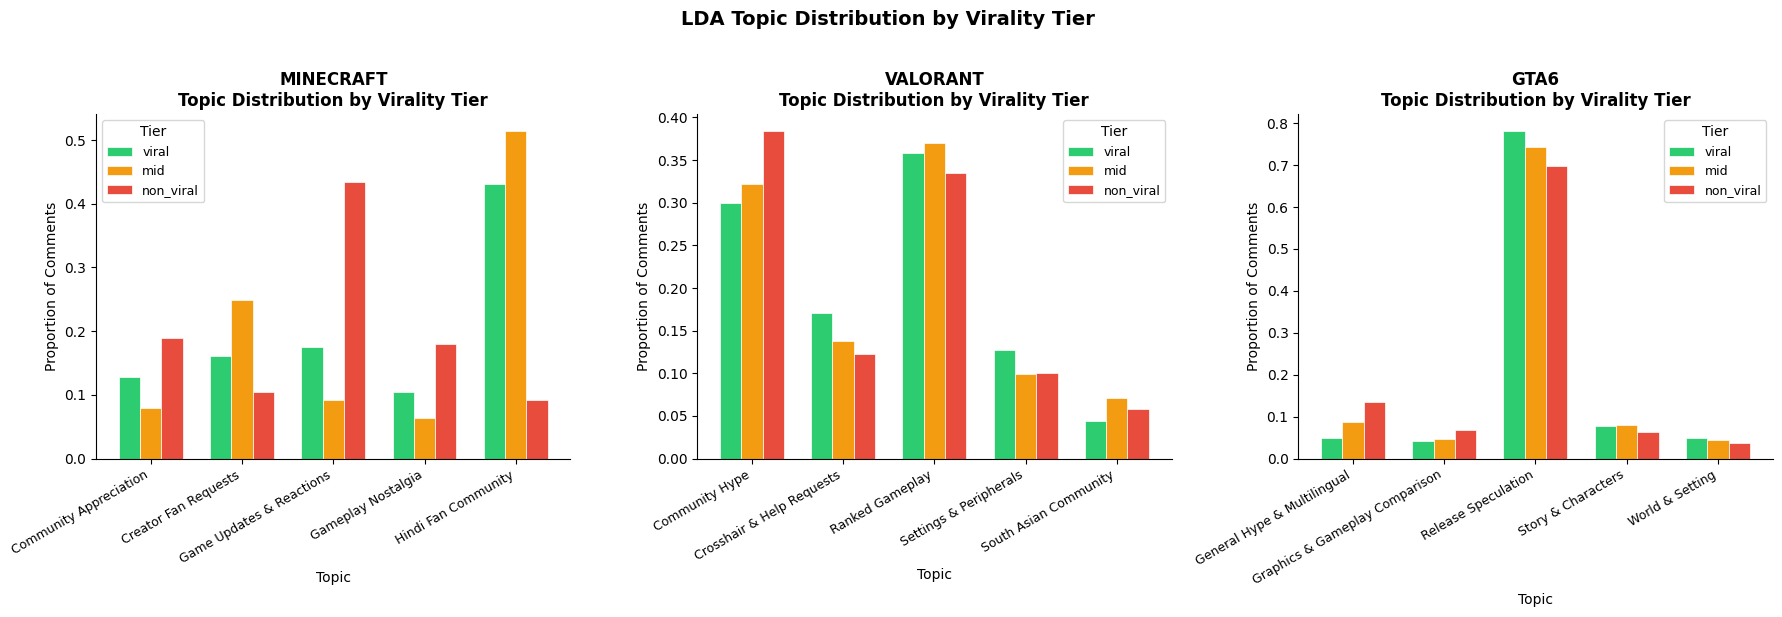

Saved: data/fig_topic_by_tier.png


In [11]:
fig, axes = plt.subplots(1, len(NICHES), figsize=(6 * len(NICHES), 6))
if len(NICHES) == 1:
    axes = [axes]

for ax, niche in zip(axes, NICHES):
    niche_data = comments_df[
        (comments_df['niche'] == niche) &
        (comments_df['virality_tier'].isin(TIER_ORDER)) &
        (comments_df['topic_label'] != 'Unknown')
    ]
    if len(niche_data) == 0:
        continue

    pivot = pd.crosstab(
        niche_data['topic_label'],
        niche_data['virality_tier'],
        normalize='columns'
    ).reindex(columns=TIER_ORDER, fill_value=0)

    pivot.plot(
        kind='bar', ax=ax, color=[TIER_COLORS[t] for t in TIER_ORDER],
        edgecolor='white', linewidth=0.5, width=0.7
    )
    ax.set_title(f'{niche.upper()}\nTopic Distribution by Virality Tier', fontsize=12, fontweight='bold')
    ax.set_xlabel('Topic', fontsize=10)
    ax.set_ylabel('Proportion of Comments', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
    ax.legend(TIER_ORDER, title='Tier', fontsize=9)

plt.suptitle('LDA Topic Distribution by Virality Tier', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/fig_topic_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/fig_topic_by_tier.png")

## Cell 12 — Visualisation 4: Word Clouds per Topic

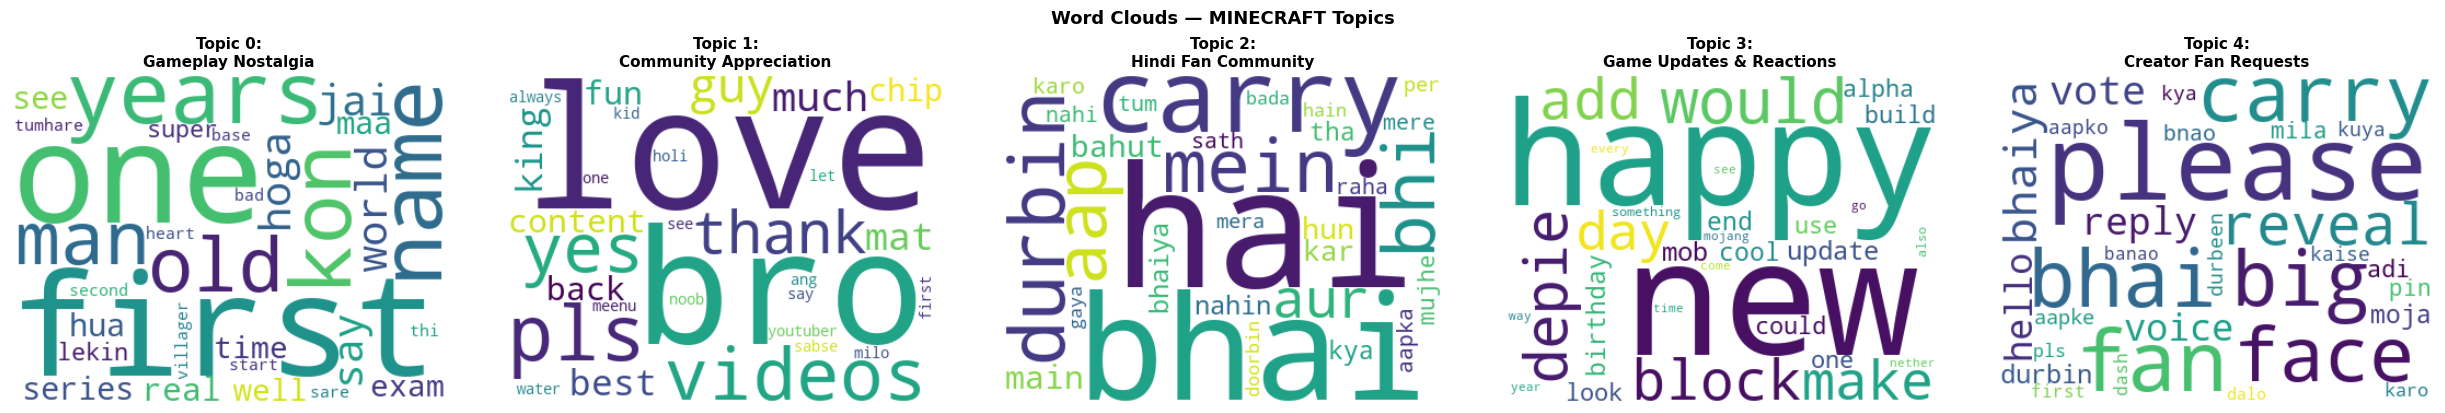

Saved: data/fig_wordcloud_minecraft.png


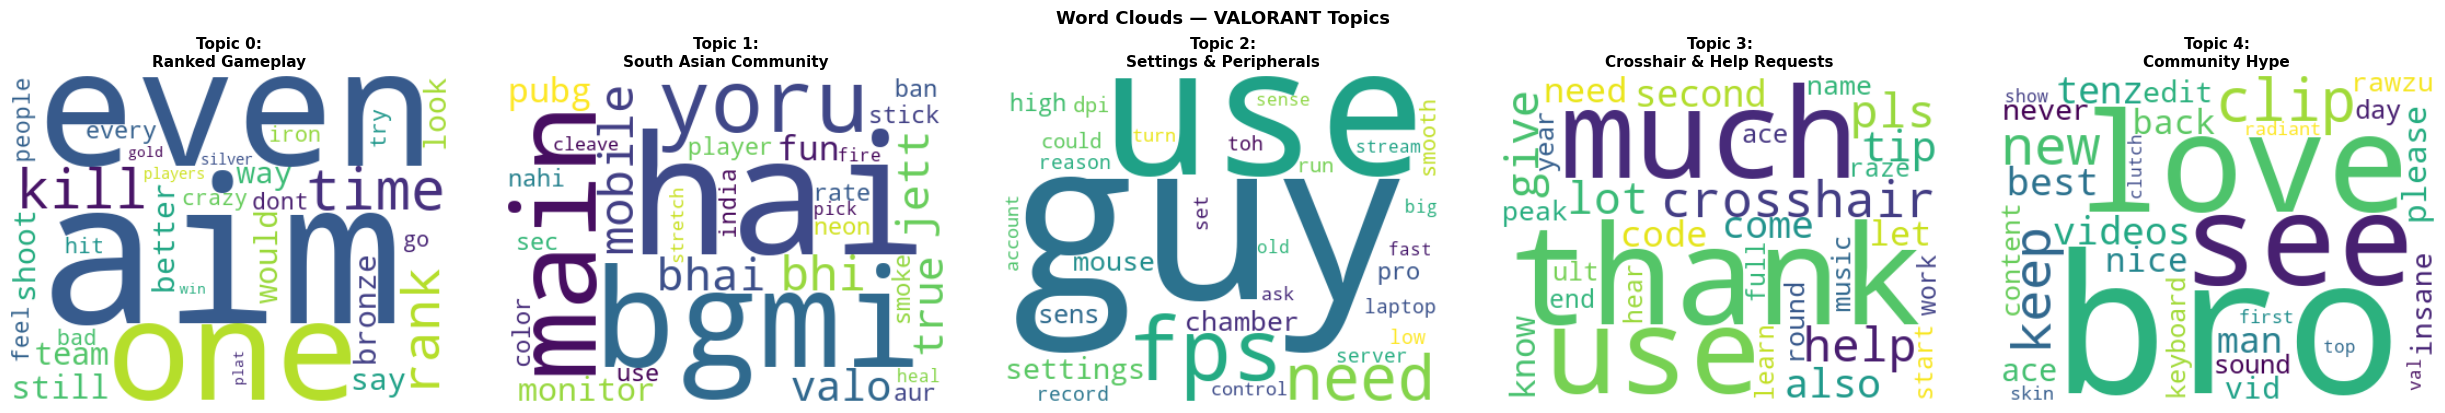

Saved: data/fig_wordcloud_valorant.png


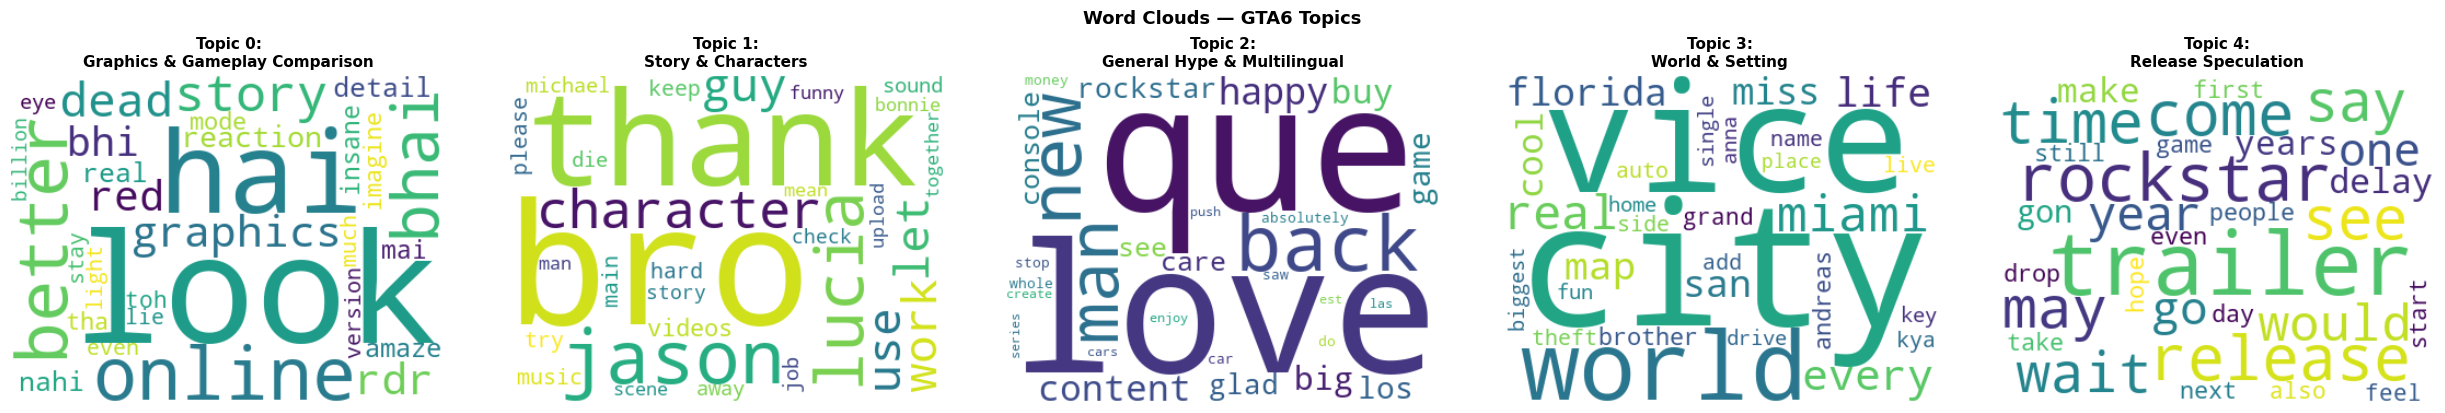

Saved: data/fig_wordcloud_gta6.png


In [12]:
for niche in NICHES:
    if niche not in lda_results:
        continue

    model = lda_results[niche]['model']
    n_topics = model.num_topics

    fig, axes = plt.subplots(1, n_topics, figsize=(5 * n_topics, 4))
    if n_topics == 1:
        axes = [axes]

    for tid, ax in enumerate(axes):
        # Get word-probability dict for this topic
        word_probs = dict(model.show_topic(tid, topn=30))
        label = TOPIC_LABELS.get(niche, {}).get(tid, f'Topic {tid}')

        wc = WordCloud(
            width=400, height=300,
            background_color='white',
            colormap='viridis',
            max_words=30
        ).generate_from_frequencies(word_probs)

        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'Topic {tid}:\n{label}', fontsize=11, fontweight='bold')
        ax.axis('off')

    plt.suptitle(f'Word Clouds — {niche.upper()} Topics', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'data/fig_wordcloud_{niche}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: data/fig_wordcloud_{niche}.png")

## Cell 13 — TF-IDF Analysis on Video Titles

In [13]:
print("Running TF-IDF analysis on video titles...")

def clean_title(text):
    """Light cleaning for titles — preserve more words than comment cleaning."""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

videos_df['clean_title'] = videos_df['title'].apply(clean_title)

tfidf_results = {}

for niche in NICHES:
    niche_videos = videos_df[videos_df['niche'] == niche].dropna(subset=['virality_tier'])
    if len(niche_videos) < 10:
        continue

    viral_titles     = niche_videos[niche_videos['virality_tier'] == 'viral']['clean_title'].tolist()
    non_viral_titles = niche_videos[niche_videos['virality_tier'] == 'non_viral']['clean_title'].tolist()

    if not viral_titles or not non_viral_titles:
        continue

    # Fit TF-IDF on all niche titles, then compare groups
    all_titles = viral_titles + non_viral_titles
    labels     = ['viral'] * len(viral_titles) + ['non_viral'] * len(non_viral_titles)

    vectorizer = TfidfVectorizer(
        max_features=200,
        stop_words='english',
        ngram_range=(1, 2),    # Include bigrams for richer features
        min_df=2
    )
    tfidf_matrix = vectorizer.fit_transform(all_titles)
    feature_names = vectorizer.get_feature_names_out()

    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
    tfidf_df['label'] = labels

    # Average TF-IDF score per term per group
    viral_avg     = tfidf_df[tfidf_df['label'] == 'viral'].drop(columns='label').mean()
    non_viral_avg = tfidf_df[tfidf_df['label'] == 'non_viral'].drop(columns='label').mean()

    # Terms more associated with viral videos
    diff = (viral_avg - non_viral_avg).sort_values(ascending=False)

    tfidf_results[niche] = {
        'viral_top': diff.head(15),
        'non_viral_top': diff.tail(15)
    }

    print(f"\n{niche.upper()} — Top 10 terms more common in VIRAL titles:")
    print(diff.head(10).to_string())
    print(f"\n{niche.upper()} — Top 10 terms more common in NON-VIRAL titles:")
    print(diff.tail(10).to_string())

print("\nTF-IDF analysis complete.")

Running TF-IDF analysis on video titles...

MINECRAFT — Top 10 terms more common in VIRAL titles:
jj                     0.106875
maizen                 0.073788
minecraft animation    0.072288
mikey                  0.064031
animation              0.062649
jj mikey               0.059915
horror                 0.051608
maizen minecraft       0.044500
coldest                0.037119
villager               0.034487

MINECRAFT — Top 10 terms more common in NON-VIRAL titles:
custom              -0.027909
meet                -0.031162
old                 -0.031819
glitch              -0.034393
testing             -0.035003
nether              -0.038960
years               -0.038960
monthly             -0.046735
minecraft monthly   -0.046735
minecraft           -0.184434

VALORANT — Top 10 terms more common in VIRAL titles:
aim             0.060794
pro             0.049383
valorant        0.048557
asmr            0.044970
dpi             0.040108
don             0.035203
immortal        0.0

## Cell 14 — Visualisation 5: TF-IDF Keyword Comparison

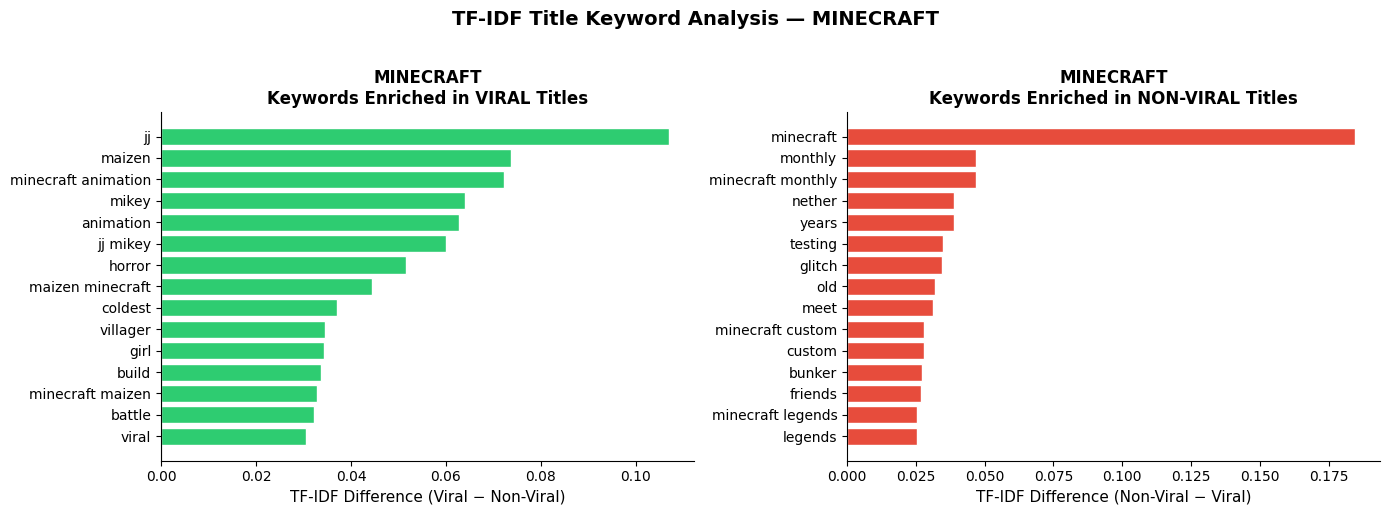

Saved: data/fig_tfidf_minecraft.png


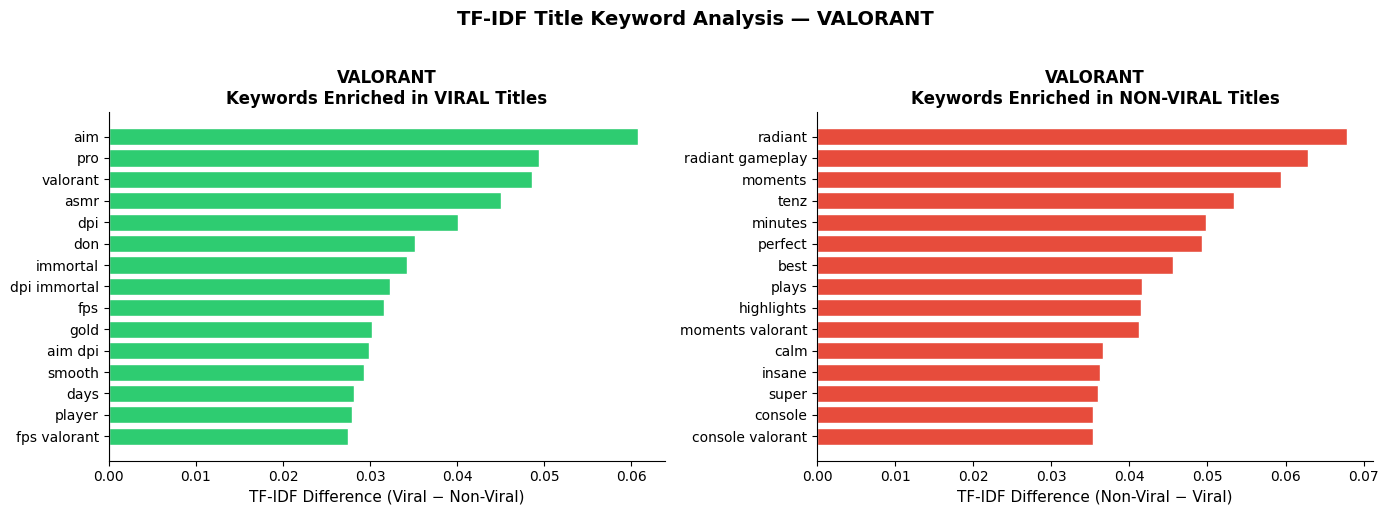

Saved: data/fig_tfidf_valorant.png


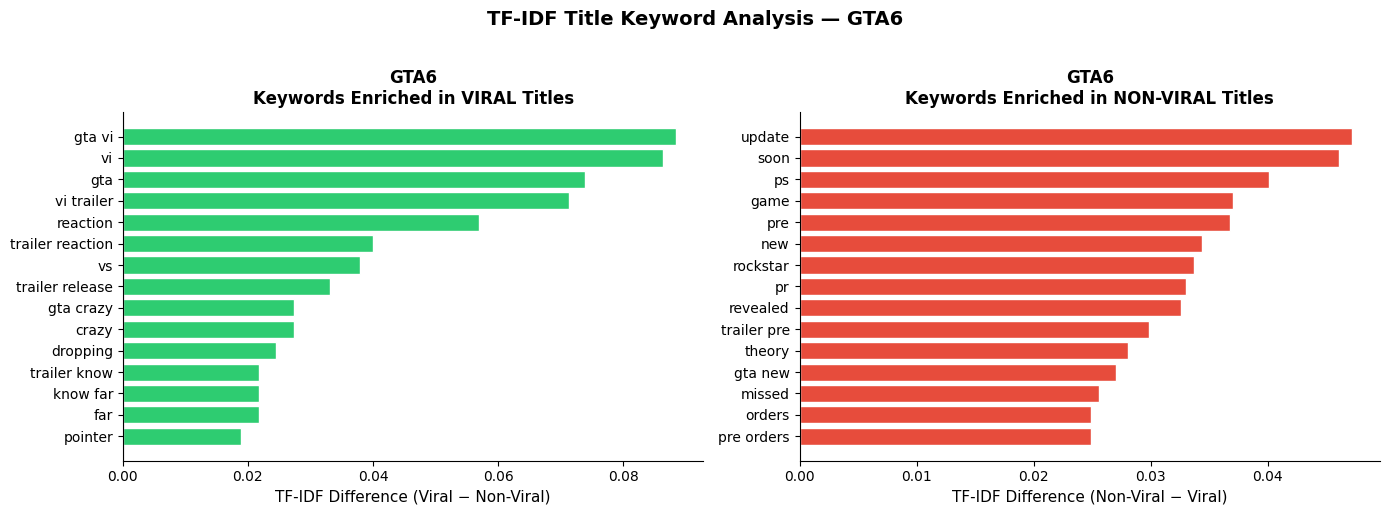

Saved: data/fig_tfidf_gta6.png


In [14]:
for niche, result in tfidf_results.items():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Viral keywords ────────────────────────────────────────────────────────
    ax = axes[0]
    viral_data = result['viral_top']
    bars = ax.barh(viral_data.index[::-1], viral_data.values[::-1],
                   color='#2ecc71', edgecolor='white')
    ax.set_xlabel('TF-IDF Difference (Viral − Non-Viral)', fontsize=11)
    ax.set_title(f'{niche.upper()}\nKeywords Enriched in VIRAL Titles', fontsize=12, fontweight='bold')
    ax.axvline(0, color='grey', linewidth=0.8)

    # ── Non-viral keywords ────────────────────────────────────────────────────
    ax2 = axes[1]
    nv_data = result['non_viral_top'].abs().sort_values(ascending=False)
    ax2.barh(nv_data.index[::-1], nv_data.values[::-1],
             color='#e74c3c', edgecolor='white')
    ax2.set_xlabel('TF-IDF Difference (Non-Viral − Viral)', fontsize=11)
    ax2.set_title(f'{niche.upper()}\nKeywords Enriched in NON-VIRAL Titles', fontsize=12, fontweight='bold')

    plt.suptitle(f'TF-IDF Title Keyword Analysis — {niche.upper()}',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'data/fig_tfidf_{niche}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: data/fig_tfidf_{niche}.png")

## Cell 15 — Compile Video-Level NLP Features & Save

In [15]:
# ── Aggregate topic distribution per video ────────────────────────────────────
video_topic = (
    comments_df.dropna(subset=['dominant_topic'])
    .groupby('video_id')
    .agg(
        dominant_topic=('dominant_topic', lambda x: x.value_counts().index[0]),
        topic_label=('topic_label', lambda x: x.value_counts().index[0]),
        avg_topic_prob=('topic_prob', 'mean')
    )
    .reset_index()
)

# ── Merge all NLP features into one video-level table ─────────────────────────
video_nlp = videos_df.merge(video_sentiment, on='video_id', how='left')
video_nlp = video_nlp.merge(video_topic, on='video_id', how='left')

video_nlp.to_csv('data/video_nlp_features.csv', index=False)

print("\n" + "="*60)
print("NLP ANALYSIS COMPLETE")
print("="*60)
print(f"""
Analyses performed:
  VADER sentiment:   {len(comments_df):,} comments scored
  LDA topics:        {NUM_TOPICS} topics per niche ({len(NICHES)} niches)
  TF-IDF titles:     {len(videos_df):,} video titles analysed

Files saved:
  data/comments_sentiment.csv     — comments with VADER scores + topic labels
  data/video_nlp_features.csv     — video-level NLP feature table
  data/lda_topics.csv             — LDA topic summaries
  data/fig_sentiment_by_tier.png
  data/fig_sentiment_kde.png
  data/fig_topic_by_tier.png
  data/fig_wordcloud_<niche>.png  — one per niche
  data/fig_tfidf_<niche>.png      — one per niche
""")


NLP ANALYSIS COMPLETE

Analyses performed:
  VADER sentiment:   29,193 comments scored
  LDA topics:        5 topics per niche (3 niches)
  TF-IDF titles:     558 video titles analysed

Files saved:
  data/comments_sentiment.csv     — comments with VADER scores + topic labels
  data/video_nlp_features.csv     — video-level NLP feature table
  data/lda_topics.csv             — LDA topic summaries
  data/fig_sentiment_by_tier.png
  data/fig_sentiment_kde.png
  data/fig_topic_by_tier.png
  data/fig_wordcloud_<niche>.png  — one per niche
  data/fig_tfidf_<niche>.png      — one per niche

